---
**PRIMER PARCIAL**  
**Nombre:** Roberto Roly Copa Mamani  
**Materia:** Machine Learning - INF 672

---

In [1]:
import itertools
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

---
**EJERCICIO 01: Una probabilidad de dos maneras: contar y simular**

Se desea calcular la probabilidad de obtener al menos un 6 al lanzar dos dados.

Primero se calculará el valor exacto enumerando los 36 resultados posibles. Luego se realizará una simulación con diferentes cantidades de lanzamientos para observar cómo la frecuencia experimental se aproxima al valor teórico.

**1. Valor exacto por conteo**

Dos dados tienen 6 posibles resultados cada uno, por lo que existen: 6 × 6 = 36 resultados posibles.

Se enumeran todos los casos y se cuentan aquellos en los que aparece al menos un 6.

In [3]:
casos = list(itertools.product(range(1, 7), repeat=2))

favorables = sum(1 for a, b in casos if a == 6 or b == 6)

total = len(casos)

probabilidad_exacta = favorables / total

print("Resultados posibles:", total)
print("Casos favorables:", favorables)
print("Probabilidad exacta:", probabilidad_exacta)

Resultados posibles: 36
Casos favorables: 11
Probabilidad exacta: 0.3055555555555556


De los 36 resultados posibles, existen 11 casos en los que aparece al menos un 6. Por tanto, la probabilidad exacta es: 0.3056  
Esto significa que existe aproximadamente un 30.56 % de probabilidad de obtener al menos un 6 al lanzar dos dados.

**2. Estimación mediante simulación**  
Ahora se simularán lanzamientos de dos dados utilizando números aleatorios.

Se utilizará una semilla fija para que los resultados puedan reproducirse. Para cada tamaño de muestra se calculará la proporción de lanzamientos en los que apareció por lo menos un 6.

In [8]:
tamanos = [100, 1000, 100000]

resultados = []

for N in tamanos:
    rng = np.random.default_rng(42)

    tiradas = rng.integers(1, 7, size=(N, 2))

    tiene_seis = np.any(tiradas == 6, axis=1)

    estimacion = tiene_seis.mean()
    error = abs(estimacion - probabilidad_exacta)

    resultados.append([N, estimacion, error])

tabla = pd.DataFrame(
    resultados,
    columns=["N", "Probabilidad estimada", "Error absoluto"]
)

tabla

,N,Probabilidad estimada,Error absoluto
0,100,0.2400,0.065556
1,1000,0.3050,0.000556
2,100000,0.3057,0.000144


**¿Cuál se acercó más y por qué?**  
La estimación que más se acercó al valor exacto fue la obtenida con **100.000 lanzamientos**, cuyo resultado fue aproximadamente 0.3057, muy próximo al valor teórico de 0.3056.  
Esto sucede porque, al aumentar la cantidad de experimentos, la frecuencia relativa tiende a estabilizarse alrededor de la probabilidad real.

**¿Qué le pasa a la estimación cuando tienes pocas tiradas?**  
Con solamente 100 lanzamientos el resultado fue 0.24, que está bastante más alejado, esto no significa que el procedimiento sea incorrecto, sino que cuando tenemos pocas observaciones existe una mayor influencia del azar.

En conclusión, mientras mayor sea el número de simulaciones, normalmente menor será la variación de la estimación respecto de la probabilidad verdadera.

---
**EJERCICIO 02: Perfil estadístico por especie y limpieza de datos**  
En este ejercicio se utilizará el conjunto de datos Iris.

Primero se realizará un análisis descriptivo de las tres especies. Posteriormente se introducirán algunos valores faltantes de manera controlada para practicar su detección e imputación.

In [9]:
iris = load_iris(as_frame=True)

df = iris.frame.copy()

df["species"] = df["target"].map(
    dict(enumerate(iris.target_names))
)

df = df.drop(columns="target")

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Las cuatro características del conjunto de datos son:

- longitud del sépalo,
- ancho del sépalo,
- longitud del pétalo,
- ancho del pétalo.

La columna `species` identifica si la flor pertenece a setosa, versicolor o virginica

**1. Perfil estadístico por especie**

Se agruparán los registros por especie y se calcularán:  
- media
- mediana
- desviación estándar
- primer cuartil (Q1)
- segundo cuartil (Q2)
- tercer cuartil (Q3)

In [12]:
columnas = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

estadisticos = df.groupby("species")[columnas].agg(
    ["mean", "median", "std",
     lambda x: x.quantile(0.25),
     lambda x: x.quantile(0.50),
     lambda x: x.quantile(0.75)]
)

estadisticos.columns = pd.MultiIndex.from_tuples([
    (
        variable,
        {
            "<lambda_0>": "Q1",
            "<lambda_1>": "Q2",
            "<lambda_2>": "Q3"
        }.get(medida, medida)
    )
    for variable, medida in estadisticos.columns
])

estadisticos.round(3)

sepal length (cm)                                sepal width (cm)  \
                        mean median    std     Q1   Q2   Q3             mean   
species                                                                        
setosa                 5.006    5.0  0.352  4.800  5.0  5.2            3.428   
versicolor             5.936    5.9  0.516  5.600  5.9  6.3            2.770   
virginica              6.588    6.5  0.636  6.225  6.5  6.9            2.974   

                                 ... petal length (cm)                    \
           median    std     Q1  ...               std   Q1    Q2     Q3   
species                          ...                                       
setosa        3.4  0.379  3.200  ...             0.174  1.4  1.50  1.575   
versicolor    2.8  0.314  2.525  ...             0.470  4.0  4.35  4.600   
virginica     3.0  0.322  2.800  ...             0.552  5.1  5.55  5.875   

           petal width (cm)                               
                       mean median    std   Q1   Q2   Q3  
species                                                   
setosa                0.246    0.2  0.105  0.2  0.2  0.3  
versicolor            1.326    1.3  0.198  1.2  1.3  1.5  
virginica             2.026    2.0  0.275  1.8  2.0  2.3  

[3 rows x 24 columns]

**Tabla de medias por especie**

Además del perfil completo, conviene observar solamente las medias porque facilitan la comparación entre las especies.

In [13]:
medias = df.groupby("species")[columnas].mean()

medias.round(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


**2. Creación de valores faltantes**  
Para simular un problema común de calidad de datos, se introducirán dos valores `NaN` en cada una de las cuatro características.  
Se utiliza una semilla fija para poder repetir el mismo experimento.

In [14]:
df_faltantes = df.copy()

rng = np.random.default_rng(42)

for columna in columnas:
    indices = rng.choice(
        df_faltantes.index,
        size=2,
        replace=False
    )

    df_faltantes.loc[indices, columna] = np.nan

print("Valores faltantes antes de imputar:")
print(df_faltantes.isna().sum())

Valores faltantes antes de imputar:
sepal length (cm)    2
sepal width (cm)     2
petal length (cm)    2
petal width (cm)     2
species              0
dtype: int64


Los valores faltantes no se reemplazarán con una mediana general de todas las flores, sino con la mediana correspondiente a su propia especie. Esto permite conservar mejor las características particulares de setosa, versicolor y virginica.

In [15]:
for columna in columnas:
    df_faltantes[columna] = (
        df_faltantes
        .groupby("species")[columna]
        .transform(lambda x: x.fillna(x.median()))
    )

print("Valores faltantes después de imputar:")
print(df_faltantes.isna().sum())

Valores faltantes después de imputar:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


**¿Por qué utilizar la mediana y no la media?**  
La mediana es una buena alternativa para reemplazar valores faltantes porque es menos sensible a valores extremos, por ejemplo, si dentro de un grupo existiera una flor con una medida excepcionalmente grande o pequeña, esta podría modificar considerablemente la media. La mediana depende principalmente de la posición central de los datos y, por ello, suele representar de manera más estable el valor típico del grupo. Además, realizar la imputación por especie evita mezclar directamente las características de flores que naturalmente presentan tamaños diferentes.

**3. Lectura de las medias por especie**  
La característica que parece separar mejor a las tres especies es la **longitud del pétalo**.  
Sus medias son aproximadamente:
- Setosa: 1.462 cm
- Versicolor: 4.260 cm
- Virginica: 5.552 cm

Se observa una diferencia clara y progresiva entre las tres especies, en cambio, el ancho del sépalo puede generar mayor confusión. Sus medias son aproximadamente:
- Setosa: 3.428 cm
- Versicolor: 2.770 cm
- Virginica: 2.974 cm

Especialmente versicolor y virginica presentan medias bastante próximas.

**¿por qué una característica con medias muy distintas entre especies separa mejor que una con medias parecidas?**  
Una característica con medias claramente distintas permite separar mejor las especies porque los grupos ocupan regiones diferentes de esa variable, cuando las medias son muy parecidas, los valores de diferentes especies pueden superponerse y resulta más difícil distinguirlas utilizando únicamente esa característica

---
**EJERCICIO 03: Tres formas de comparar dos flores**  
Cada flor será representada por un vector con sus cuatro características.  
Se implementarán tres formas de comparación:

1. Distancia euclidiana.
2. Producto punto.
3. Similitud coseno.

La distancia euclidiana indica qué tan separados están dos vectores, mientras que la similitud coseno mide qué tan parecida es su orientación, y el producto punto mide la relación entre ambos vectores considerando tanto sus valores como su orientación

In [16]:
iris = load_iris()

X = iris.data
y = iris.target
nombres = iris.target_names

**1. Funciones**  
Las tres operaciones se implementan directamente con NumPy

In [17]:
def distancia_euclidiana(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def producto_punto(a, b):
    return np.sum(a * b)


def similitud_coseno(a, b):
    return np.dot(a, b) / (
        np.linalg.norm(a) * np.linalg.norm(b)
    )

**2. Flores seleccionadas**  
Se seleccionaron las siguientes flores:
- Índice 0: setosa
- Índice 1: setosa
- Índice 50: versicolor
- Índice 100: virginica

Los índices 0 y 1 permiten comparar dos flores de la misma especie.  
Los otros pares permiten observar qué ocurre cuando se comparan flores pertenecientes a especies diferentes.

In [18]:
indices = [0, 1, 50, 100]

for i in indices:
    print(
        "Índice:", i,
        "| Especie:", nombres[y[i]],
        "| Valores:", X[i]
    )

Índice: 0 | Especie: setosa | Valores: [5.1 3.5 1.4 0.2]
Índice: 1 | Especie: setosa | Valores: [4.9 3.  1.4 0.2]
Índice: 50 | Especie: versicolor | Valores: [7.  3.2 4.7 1.4]
Índice: 100 | Especie: virginica | Valores: [6.3 3.3 6.  2.5]


**3. Comparación de los pares**  
Se compararán los siguientes pares:
- 0 y 1: misma especie.
- 0 y 50: especies diferentes.
- 50 y 100: especies diferentes.

De esta manera no solo se compara un par similar y uno diferente, sino que también podemos observar cómo cambian las medidas entre distintos grupos

In [19]:
pares = [
    (0, 1),
    (0, 50),
    (50, 100)
]

resultados = []

for i, j in pares:

    resultados.append([
        f"{i} - {j}",
        nombres[y[i]],
        nombres[y[j]],
        distancia_euclidiana(X[i], X[j]),
        producto_punto(X[i], X[j]),
        similitud_coseno(X[i], X[j])
    ])

tabla_comparacion = pd.DataFrame(
    resultados,
    columns=[
        "Par",
        "Especie A",
        "Especie B",
        "Distancia euclidiana",
        "Producto punto",
        "Similitud coseno"
    ]
)

tabla_comparacion.round(4)

,Par,Especie A,Especie B,Distancia euclidiana,Producto punto,Similitud coseno
0,0 - 1,setosa,setosa,0.5385,37.49,0.9986
1,0 - 50,setosa,versicolor,4.0037,53.76,0.9284
2,50 - 100,versicolor,virginica,1.8439,86.36,0.9821


**¿Las flores de la misma especie salieron «más parecidas» (menor distancia, mayor coseno)?**  
Sí, las dos flores de la misma especie resultaron ser las más parecidas, el par formado por las flores 0 y 1, ambas setosa, presenta la menor distancia euclidiana (0.5385) y la similitud coseno más alta (0.9986)

Un coseno cercano a 1 indica que los vectores tienen una orientación muy parecida.  
Entre los pares de diferentes especies, versicolor y virginica resultaron más similares entre sí que setosa y versicolor.

**¿La distancia euclidiana y la similitud coseno ordenan las flores igual?**  
En estas comparaciones, la distancia euclidiana y la similitud coseno sí producen el mismo orden general de similitud:

1. 0 - 1: más parecido.
2. 50 - 100: similitud intermedia.
3. 0 - 50: menos parecido.

Sin embargo, no significa que ambas medidas siempre deban ordenar los datos exactamente igual, la distancia euclidiana considera la diferencia directa entre las magnitudes de los valores, mientras que el coseno se concentra principalmente en la dirección de los vectores

---
**EJERCICIO 04: Bajar la colina: descenso de gradiente**  
Se trabajará con la función: f(x) = (x - 4)² + 1  
Su mínimo verdadero se encuentra en: x = 4  
y su derivada es: f'(x) = 2(x - 4)  
El descenso de gradiente utiliza la derivada para decidir hacia dónde modificar x en cada iteración.

**1. Funciones necesarias**  
El descenso de gradiente será: x = x - tasa * f'(x)

El proceso comenzará en x = 10 y se realizarán 20 pasos.

In [20]:
def f(x):
    return (x - 4) ** 2 + 1


def derivada(x):
    return 2 * (x - 4)


def descenso_gradiente(tasa, pasos=20):
    x = 10.0

    trayectoria = [x]

    for _ in range(pasos):
        x = x - tasa * derivada(x)
        trayectoria.append(x)

    return trayectoria

**2. Tasas de aprendizaje**  
Se probarán las tres tasas indicadas:
- 0.01: pequeña.
- 0.1: intermedia.
- 1.1: grande.

In [21]:
tasas = [0.01, 0.1, 1.1]

trayectorias = {}

for tasa in tasas:
    trayectorias[tasa] = descenso_gradiente(tasa, pasos=20)

**Trayectoria con tasa 0.01**

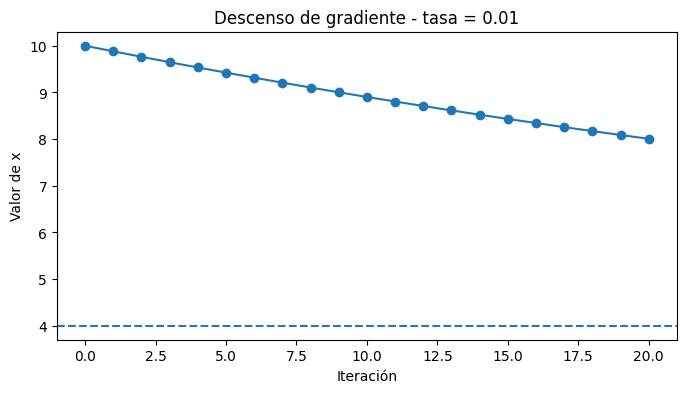

In [22]:
plt.figure(figsize=(8, 4))

plt.plot(trayectorias[0.01], marker="o")
plt.axhline(4, linestyle="--")

plt.xlabel("Iteración")
plt.ylabel("Valor de x")
plt.title("Descenso de gradiente - tasa = 0.01")

plt.show()

**Trayectoria con tasa 0.1**

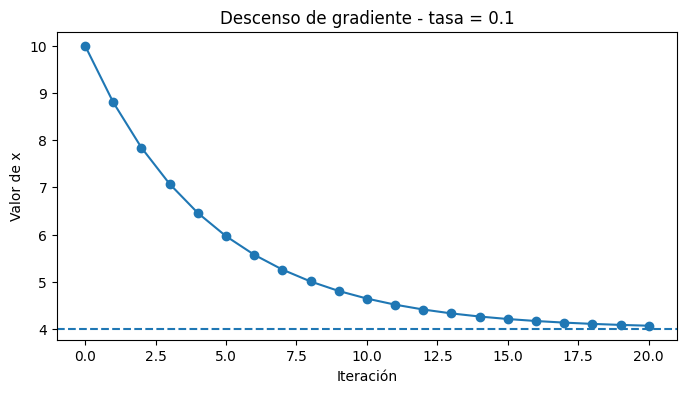

In [23]:
plt.figure(figsize=(8, 4))

plt.plot(trayectorias[0.1], marker="o")
plt.axhline(4, linestyle="--")

plt.xlabel("Iteración")
plt.ylabel("Valor de x")
plt.title("Descenso de gradiente - tasa = 0.1")

plt.show()

**Trayectoria con tasa 1.1**

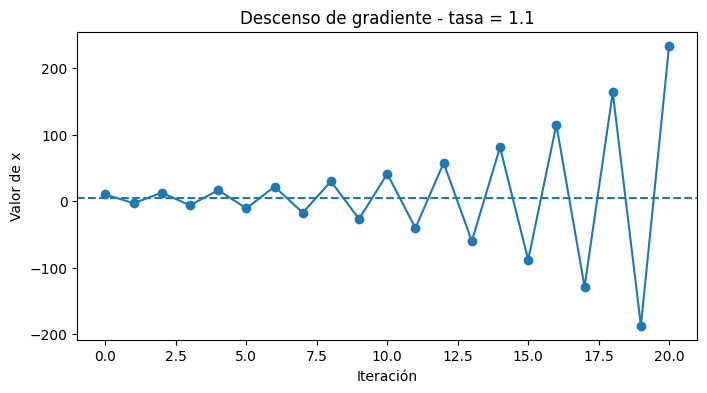

In [24]:
plt.figure(figsize=(8, 4))

plt.plot(trayectorias[1.1], marker="o")
plt.axhline(4, linestyle="--")

plt.xlabel("Iteración")
plt.ylabel("Valor de x")
plt.title("Descenso de gradiente - tasa = 1.1")

plt.show()

**3. Comparación del resultado final con x = 4**  
Se calcula el valor final obtenido después de las 20 iteraciones y su distancia respecto del mínimo verdadero

In [25]:
comparacion = []

for tasa in tasas:
    x_final = trayectorias[tasa][-1]

    error = abs(x_final - 4)

    comparacion.append([
        tasa,
        x_final,
        error
    ])

tabla_final = pd.DataFrame(
    comparacion,
    columns=[
        "Tasa de aprendizaje",
        "x final",
        "Distancia respecto a x=4"
    ]
)

tabla_final.round(6)

,Tasa de aprendizaje,x final,Distancia respecto a x=4
0,0.01,8.005648,4.005648
1,0.10,4.069175,0.069175
2,1.10,234.025600,230.025600


Las tres tasas de aprendizaje producen comportamientos muy diferentes.

**¿todas llegan cerca del mínimo? ¿Qué pasa con la tasa muy pequeña (¿avanza lento?) y con la muy grande (¿se pasa, oscila o se dispara?)?**  
**Tasa 0.01**  
La tasa 0.01 se mueve en la dirección correcta hacia x = 4, pero avanza lentamente, después de 20 iteraciones todavía se encuentra aproximadamente en x = 8.0056. Por tanto, no es una tasa incorrecta, pero necesita muchas más iteraciones para acercarse al mínimo

**Tasa 0.1**  
La tasa 0.1 presenta el comportamiento más adecuado de las tres. Después de 20 pasos alcanza aproximadamente: (x = 4.0692), que está muy cerca del mínimo verdadero x = 4, esto ocurre porque el tamaño de los pasos permite avanzar de forma considerable sin sobrepasar excesivamente el mínimo

**Tasa 1.1**  
La tasa 1.1 es demasiado grande, en lugar de acercarse progresivamente al mínimo, x comienza a pasar de un lado al otro de x = 4 y cada oscilación aumenta de tamaño, por ejemplo, los primeros valores son aproximadamente: 10 → -3.2 → 12.64 → -6.368 → 16.4416 ...  
Esto demuestra que el algoritmo está divergiendo, después de 20 iteraciones alcanza aproximadamente x = 234.03, muy lejos del mínimo

**Conclusión**  
No todas las tasas llegan cerca del mínimo.  
Una tasa demasiado pequeña puede aprender correctamente, pero muy lentamente. Una tasa intermedia puede producir una convergencia rápida y estable. En cambio, una tasa excesivamente grande puede hacer que el algoritmo sobrepase continuamente el mínimo y termine divergiendo.